In [79]:
import pandas as pd
import matplotlib.pyplot as plt

In [80]:
DATA_PATH = r'..\data\splice.data'
COLLUMNS = ["class", "name", "sequence"]

In [81]:
dataframe = pd.read_csv(filepath_or_buffer=DATA_PATH, header=None, names=COLLUMNS)

In [82]:
dataframe.head(5)

,class,name,sequence
0,EI,ATRINS-DONOR-521,CCAGCTGCATCACAGGAGGCCAGCGAGCAGG...
1,EI,ATRINS-DONOR-905,AGACCCGCCGGGAGGCGGAGGACCTGCAGGG...
2,EI,BABAPOE-DONOR-30,GAGGTGAAGGACGTCCTTCCCCAGGAGCCGG...
3,EI,BABAPOE-DONOR-867,GGGCTGCGTTGCTGGTCACATTCCTGGCAGGT...
4,EI,BABAPOE-DONOR-2817,GCTCAGCCCCCAGGTCACCCAGGAACTGACGTG...


In [83]:
dataframe.shape

(3190, 3)

In [84]:
dataframe['class'].value_counts()

class
N     1655
IE     768
EI     767
Name: count, dtype: int64

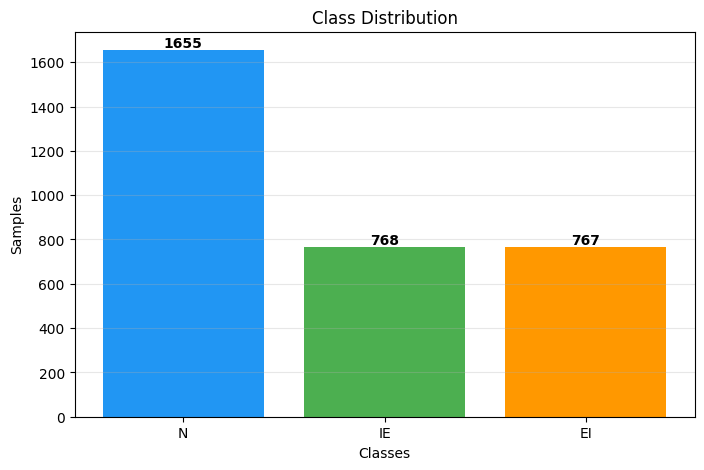

In [85]:
counts = dataframe['class'].value_counts()
class_names = counts.index.tolist()
samples_per_class = counts.values.tolist()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(class_names, samples_per_class, facecolor=['#2196F3', '#4CAF50', '#FF9800'])
plt.grid(axis='y', alpha=0.3)
for i, (name, value) in enumerate(zip(class_names, samples_per_class)):
    ax.text(i, value + 10, str(value), ha='center', fontweight='bold')
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Samples")

plt.show()

In [91]:
dataframe['count_A'] = dataframe['sequence'].apply(lambda x: x.count('A'))
dataframe['count_T'] = dataframe['sequence'].apply(lambda x: x.count('T'))
dataframe['count_G'] = dataframe['sequence'].apply(lambda x: x.count('G'))
dataframe['count_C'] = dataframe['sequence'].apply(lambda x: x.count('C'))
dataframe.head()

,class,name,sequence,count_A,count_T,count_G,count_C
0,EI,ATRINS-DONOR-521,CCAGCTGCATCACAGGAGGCCAGCGAGCAGG...,12,10,19,19
1,EI,ATRINS-DONOR-905,AGACCCGCCGGGAGGCGGAGGACCTGCAGGG...,8,4,21,27
2,EI,BABAPOE-DONOR-30,GAGGTGAAGGACGTCCTTCCCCAGGAGCCGG...,12,7,27,14
3,EI,BABAPOE-DONOR-867,GGGCTGCGTTGCTGGTCACATTCCTGGCAGGT...,4,17,23,16
4,EI,BABAPOE-DONOR-2817,GCTCAGCCCCCAGGTCACCCAGGAACTGACGTG...,10,10,14,26


In [92]:
dataframe.groupby('class')[['count_A', 'count_T', 'count_G', 'count_C']].mean()

,count_A,count_T,count_G,count_C
class,,,,
EI,13.292047,13.062581,18.848761,14.736636
IE,12.346354,15.867188,13.429688,18.352865
N,14.990937,14.563746,15.392145,15.046526
